In [9]:
"""
%% Exemple 5 PI 1r ordre
%  J.A.Mayugo, UdG, 2023
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

In [10]:
U  = 5;         # % V, input 'bump test'
omega_ss= 104;  # % rad/s
t0 = 300e-3;    # % s
t1 = 375e-3;    # % s

omega_n = 25;   # % rad/s
zeta    = 1;    # % críticament esmorteït

tau = t1-t0;
K = omega_ss/U;

# % Model
numG = [K]
denG = [tau, 1]
tf_G_m = signal.lti(numG, denG)

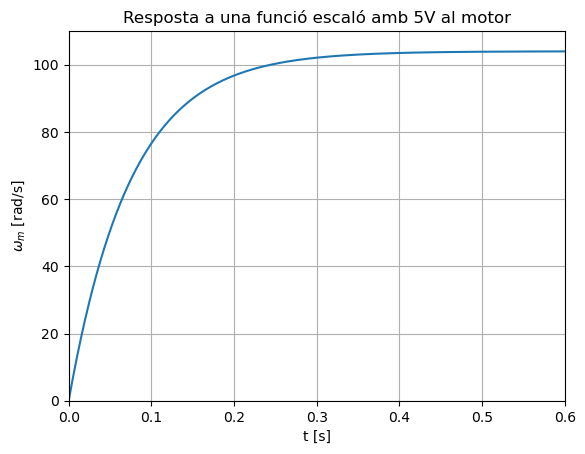

In [11]:
# % Resposta transitòria: escaló en llaç obert:

tRange = np.linspace(0, 0.6, num=1000)

t, y = tf_G_m.step(T=tRange)
# t, y = signal.step2(tf_G_m,T=tRange)
plt.figure()
plt.plot(t, y*U)
plt.xlabel('t [s]')
plt.ylabel('$\omega_m$ [rad/s]')
plt.title('Resposta a una funció escaló amb ' + str(U) + 'V al motor')
plt.xlim([0, t[-1]])
plt.ylim([0, 110])
plt.grid()

Pols del sistema
[-13.33333333]


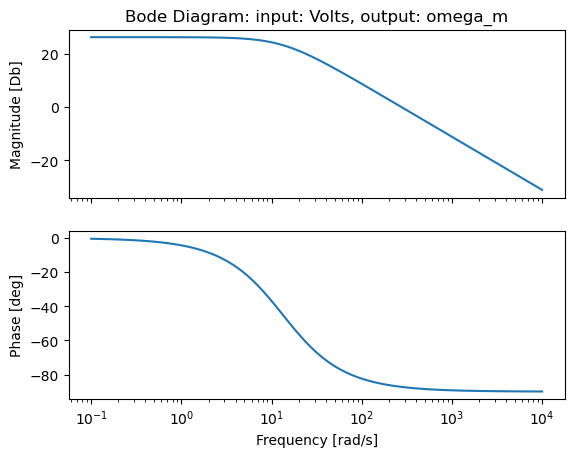

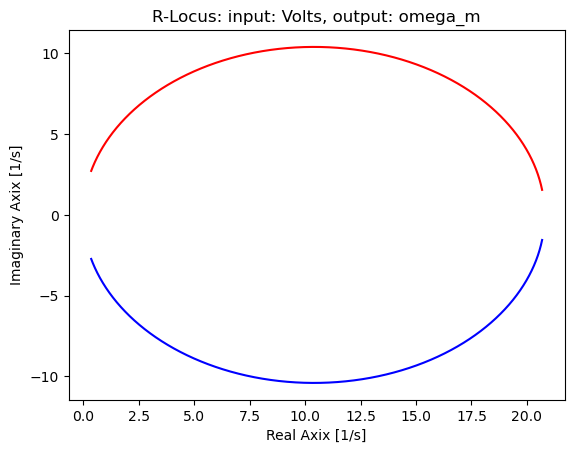

In [12]:
# % Diagrama de Bode i R-Locus
wRange = np.logspace(np.log10(0.1), np.log10(1e4), num=100)
w, mag, phase = tf_G_m.bode(w=wRange)

plt.subplots(2, 1, sharex='col')
plt.subplot(2, 1, 1)
plt.semilogx(w, mag)    # Bode magnitude plot
plt.title('Bode Diagram: input: Volts, output: omega_m')
plt.ylabel('Magnitude [Db]')
plt.subplot(2, 1, 2)
plt.semilogx(w, phase)  # Bode phase plot
plt.ylabel('Phase [deg]')
plt.xlabel('Frequency [rad/s]')

w, H = tf_G_m.freqresp()
plt.figure()
plt.plot(H.real, H.imag, "b")
plt.plot(H.real, -H.imag, "r")
plt.xlabel('Real Axix [1/s]')
plt.ylabel('Imaginary Axix [1/s]')
plt.title('R-Locus: input: Volts, output: omega_m')

print('Pols del sistema')
print(tf_G_m.poles)

In [13]:
# % control velocitat llaç tancat considerant un sistema de 2n ordre

Kp = (2*zeta*omega_n*tau-1)/K 
Ki = omega_n**2*tau/K

print(f'Contrololador PID, paràmetre K_p {Kp:.4f}')
print(f'Contrololador PID, paràmetre K_i {Ki:.4f}')

# PI = Kp + Ki/s             # % controlador PI
numC = [Kp, Ki]
denC = [1, 0]

num_ol = np.polymul(numC, numG)
den_ol = np.polymul(denC, denG)

# feedback manual: T = N / (D + N)
    # model_G_cl = PI*model_G_m/(1+PI*model_G_m)   # % model llaç tancat amb PI, fórmula de Mason
num_cl = num_ol
den_cl = np.polyadd(den_ol, num_ol)

tf_G_cl = signal.lti(num_cl, den_cl)   

print('Pols del sistema')
print(tf_G_cl.poles)

Contrololador PID, paràmetre K_p 0.1322
Contrololador PID, paràmetre K_i 2.2536
Pols del sistema
[-25.00000042 -24.99999958]


(0.0, 110.0)

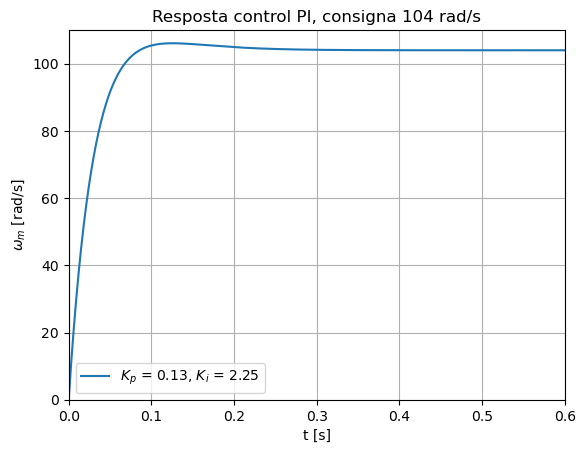

In [14]:

t, y = tf_G_cl.step(T=tRange)
# t, y = signal.step2(tf_G_cl,T=tRange)

plt.figure()
plt.plot(t, y*omega_ss)
plt.xlabel('t [s]')
plt.ylabel('$\omega_m$ [rad/s]')
plt.title('Resposta control PI, consigna ' + str(omega_ss) + ' rad/s')
plt.grid()
plt.legend(["$K_p$ = " + str(round(Kp,2)) + ", $K_i$ = " + str(round(Ki,2))])
plt.xlim([0, t[-1]])
plt.ylim([0, 110])

In [15]:

e_v=1/(Ki*K)  #% rad/s2, error en la derivada de del valor de sortida

print(["L'error estacionari és de velocitat és "+ str(round(e_v,4))+' rad/s2'])

["L'error estacionari és de velocitat és 0.0213 rad/s2"]


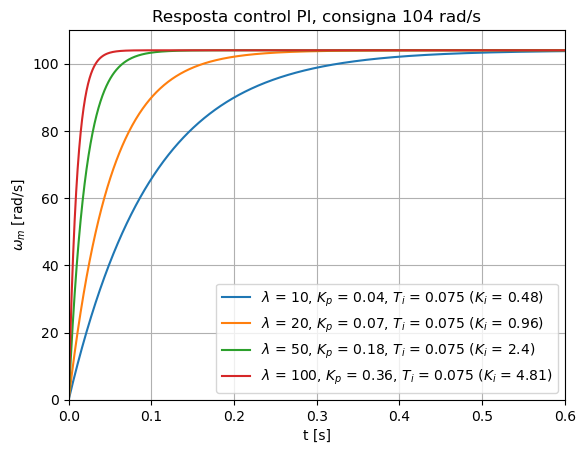

In [16]:
# %% Alternativa) Direct Syntesis Method
# % control velocitat llaç tancat controlador PI

lambda_ = np.array([10, 20, 50, 100])
u = omega_ss;
Kp_ = np.zeros(lambda_.shape[0])
y_  = np.zeros([lambda_.shape[0],tRange.shape[0]])

for ii in range(lambda_.shape[0]):

    Kp_[ii] = tau/K * lambda_[ii]
    Ti = tau
    
    numC = [Kp_[ii]*Ti, Kp_[ii]]        # PI: Kp*(1 + 1/(Ti*s))
    denC = [Ti, 0]

    # llaç obert
    num_ol = np.polymul(numC, numG)
    den_ol = np.polymul(denC, denG)

    # llaç tancat: T = N / (D + N)
    num_cl = num_ol
    den_cl = np.polyadd(den_ol, num_ol)

    sys_cl = signal.lti(num_cl, den_cl)

    t, y = signal.step(sys_cl, T=tRange)
    y_[ii, :] = y


# legend_=string(lambda_);
plt.figure()
for ii in range(0,lambda_.shape[0]):
    plt.plot(t, y_[ii,:]*omega_ss,
             label='$\lambda$ = ' + str(round(lambda_[ii],0)) + 
                   ", $K_p$ = " + str(round(Kp_[ii],2)) + 
                   ", $T_i$ = " + str(round(Ti,3)) + 
                   ' ($K_i$ = '  + str(round(Kp_[ii]/Ti,2)) +')' ) 
plt.title('Resposta control PI, consigna ' + str(omega_ss) + ' rad/s')
plt.grid()
plt.xlabel('t [s]')
plt.ylabel('$\omega_m$ [rad/s]')
plt.legend()
plt.xlim([0, t[-1]])
plt.ylim([0, 110])

plt.show()